## Hugging Face

Here are some simple examples of using pre-trained models from Hugging Face for some tasks. Here I chose 1 image model and 1 image to text model and 1 generate text model.

Hugging face models: https://huggingface.co/models

Installation of hugging face

In [1]:
#pip install -U transformers datasets evaluate accelerate timm


In [21]:
#pip install pytorch

## Image

In [2]:
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image
import requests
import matplotlib.pyplot as plt
import torch.nn as nn

/Users/ziqili/anaconda3/lib/python3.11/site-packages/transformers/utils/deprecation.py:172: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type'
  return func(*args, **kwargs)


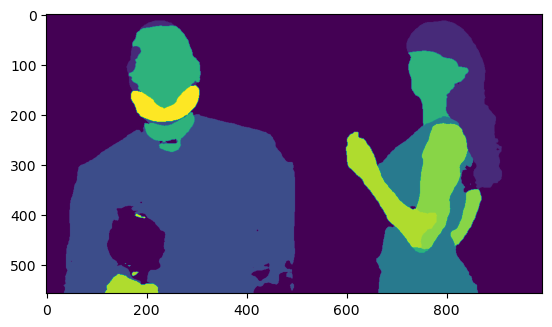

In [3]:
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image
import requests
import matplotlib.pyplot as plt
import torch.nn as nn

processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes")

url = "https://i.abcnewsfe.com/a/9029f3ea-3f8d-4c47-baed-0b580882d5fa/lebron-swift-gty-jef-250401_1743536393912_hpMain_16x9.jpg?w=992"

image = Image.open(requests.get(url, stream=True).raw)
inputs = processor(images=image, return_tensors="pt")

outputs = model(**inputs)
logits = outputs.logits.cpu()

upsampled_logits = nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False,
)

pred_seg = upsampled_logits.argmax(dim=1)[0]
plt.imshow(pred_seg)

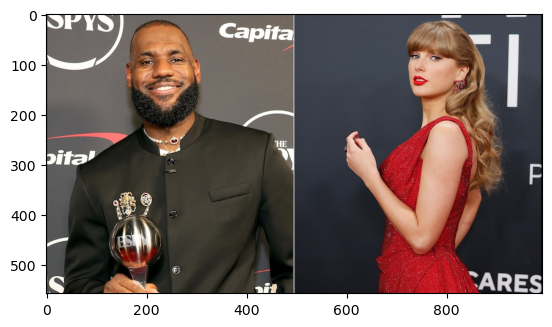

In [4]:
plt.imshow(image)

## Image to Text

In [5]:

from transformers import BlipProcessor, BlipForConditionalGeneration

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

url

url_2 = "https://media.istockphoto.com/id/1318323972/photo/an-old-fashioned-traditional-ice-cream-van.jpg?s=612x612&w=0&k=20&c=d_lgZXOq-jdypIT9fKWV356HwvXykIqKc4y_4w90pjo="

raw_image = Image.open(requests.get(url_2, stream=True).raw).convert('RGB')

# unconditional image captioning
inputs = processor(raw_image, return_tensors="pt")

out = model.generate(**inputs)
print(processor.decode(out[0], skip_special_tokens=True))

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


a food truck parked on the side of a road


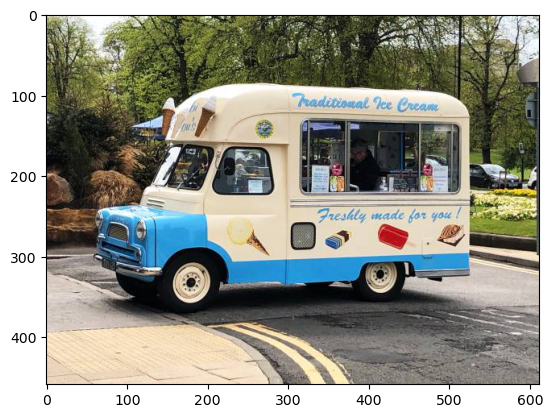

In [6]:
plt.imshow(raw_image)

## A Generative Language Model

In [12]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)



config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [19]:
%%time

prompt = "Give me a short introduction to large language model."
prompt2 = "What is Moran's I"

messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt2}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=128 #Size of the response
)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

CPU times: user 9.97 s, sys: 382 ms, total: 10.4 s
Wall time: 10.9 s


In [20]:
response

"Moran's I (also known as the Moran's I statistic) is a measure of association between two variables that can be used to analyze spatial data. It was introduced by Francis H. Moran in 1926 and has since become a widely used statistical tool for assessing relationships between geographic features or locations.\n\nHere are some key points about Moran's I:\n\n1. Definition: Moran's I measures how often observations fall within clusters of other observations.\n\n2. Calculation: The formula for Moran's I is:\n   \\[\n   I = \\frac{S}{\\sqrt{N}}\n   \\]\n   where \\( S \\)"